# Version un peu plus avancée du code "tuto_plot.ipynb": le but ici est de pouvoir combiner plusieurs graphes sur une seule figure (savoir faire des panneaux de figures)

##### Écrit 13 mars 2026

In [1]:
import numpy as np

# Modules pour lire les données netCDF
import netCDF4
from netCDF4 import Dataset

# Modules pour tracer des graphiques en Python

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# CARTOPY = tracer des cartes
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# cmocean = colorbars adaptées pour données océano
import cmocean

/home/analivaev/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Lire les données: on va lire des sorties de concentration de chlorophylle de surface, issues de trois modèles différents

(à modifier pour Céleste: mettre le zooplancton en donnée d'entrée)

In [3]:
# Définir d'abord le répertoire où on stocke les données
rep_model='/home/analivaev/Documents/THESE/Data/CMIP6/historical/CHL/New_version/'

# Définir les noms des fichiers
file_IPSL='monmean_SO_chl_Omon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_199801-201412.nc'
file_ESM4='monmean_SO_chl_Omon_GFDL-ESM4_historical_r1i1p1f1_gr_199801-201412.nc'
file_MPI='monmean_SO_chl_Omon_MPI-ESM1-2-HR_historical_r1i1p1f1_gr_199801-201412.nc'

# On lit les données contenues dans les fichiers grace à la fonction Dataset du module netCDF4
data_IPSL=Dataset(rep_model+file_IPSL,'r',format='NETCDF4')
data_ESM4=Dataset(rep_model+file_ESM4,'r',format='NETCDF4')
data_MPI=Dataset(rep_model+file_MPI,'r',format='NETCDF4')

In [4]:
# Définir des raccourcis pour appeler les variables
lon,lat=data_IPSL.variables['lon'][:],data_IPSL.variables['lat'][:]
# Normalement les trois fichiers partagent les mêmes dimensions time,lat, lon, mais on peut vérifier

chl_IPSL=data_IPSL.variables['chl'][:,:,:]
chl_ESM4=data_ESM4.variables['chl'][:,:,:]
chl_MPI=data_MPI.variables['chl'][:,:,:]

print(np.shape(chl_IPSL),np.shape(chl_ESM4),np.shape(chl_MPI))
# np.shape --> pour connaître les dimensions d'un objet (ici une matrice 3D)

(12, 60, 360) (12, 60, 360) (12, 60, 360)


On peut vouloir **calculer des moyennes d'une variable sur une coordonnée**: par exemple, ici, on pourrait vouloir tracer la moyenne annuelle des concentrations de chlorophylle, ou la moyenne de certains mois (je prends l'exemple de Novembre Décembre Janvier).

On utilise la fonction **np.nanmean(chl, axis= ...)** où axis=... spécifie l'axe selon lequel on moyenne les données.
Par exemple, np.nanmean(chl_IPSL, axis=0) moyennera toutes les concentrations de chlorophylle (modèle IPSL) sur la première coordonnée - la coordonnée temps.

In [6]:
chl_IPSL_yearly=np.nanmean(chl_IPSL,axis=0)
chl_MPI_yearly=np.nanmean(chl_MPI,axis=0)
chl_ESM4_yearly=np.nanmean(chl_ESM4,axis=0)

print(chl_IPSL_yearly,chl_MPI_yearly,chl_ESM4_yearly)

# NB: dans mes données j'ai une incohérence d'unités sur le fichier IPSL: les données sont en g/m3 au lieu de kg/m3.
# Je convertis plus tard tout en mg/m3 (unité usuelle de la chlorophylle)

print(np.shape(chl_IPSL_yearly)) # fichier lat, lon, avec la moyenne sur la coordonnée temps du fichier précédent

[[-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 ...
 [0.00019924195657949895 0.00019579549552872777 0.00018846664170268923
  ... 0.00019727354811038822 0.00019799820438493043
  0.00019857259758282453]
 [0.00018574342539068311 0.0001831652334658429 0.00017641934391576797 ...
  0.00018497201381251216 0.00018549647938925773 0.0001856494345702231]
 [0.00017097342060878873 0.00016785593470558524 0.00016128674906212837
  ... 0.00017355185991618782 0.00017314644355792552 0.0001726158516248688]] [[-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 ...
 [4.798569648301054e-07 4.934398134537332e-07 5.032645162827976e-07 ...
  5.111198220220103e-07 4.831351247958082e-07 4.645573028483341e-07]
 [3.9035293752931466e-07 4.0347322283196263e-07 4.108560460736044e-07 ...
  3.9358883441309445e-07 3.8266719570856367e-07 3.9059000300767366e-07]
 [3.3528394283166563e-07 3.443550440351828e-07 3.389261848951719e-07 ...
  3.4413895377838344e-07 3.423161558657

On peut regarder d'autres statistiques: standard deviation, medianes etc. fonctions: np.nanstd, np.nanmedian.
Par ailleurs, je demande spécifiquement np.**nan**mean et non np.mean pour être sûr que les entrées Not A Number (NaNs, ou np.nan en Python) soient omises du calcul.
(Avec une variable associée à un masque comme celles de CMIP6, normalement les NaNs ne posent pas de problème. Mais parfois on a des arrays avec des entrées NaN que la fonction moyenne np.mean ne sait pas gérer). 

In [16]:
# Si on ne spécifie pas l'axe sur lequel calculer la moyenne, Python moyenne sur tous les axes.
print(np.nanmean(chl_IPSL))
print(np.nanstd(chl_IPSL))

0.00037681384
0.00034056118


Enfin, si on veut moyenner sur certains mois spécifiquement, il faut indiquer quels mois choisir.

In [18]:
NDJ_months=[0,10,11] # les indices des mois de Janvier, Novembre, Décembre

chl_IPSL_NDJ=np.nanmean(chl_IPSL[NDJ_months,:,:],axis=0)
chl_MPI_NDJ=np.nanmean(chl_MPI[NDJ_months,:,:],axis=0)
chl_ESM4_NDJ=np.nanmean(chl_ESM4[NDJ_months,:,:],axis=0)


### Exemple de plots:

On va utiliser la fonction plt.subplots de matplotlib pour avoir plusieurs petites figures sur un même panneau.

Documentation ici, avec beaucoup d'exemples: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html

En bref, la manière dont cela marche:
- on indique un certain nombre de colonnes et lignes (nrows=n, ncols=m) en argument de plt.subplots
- la fonction crée m x n objets axs (les axes qu'on utilise pour tracer les plots). Ici j'ai trois objets axs, axs[0], axs[1], axs[2] qui vont correspondre aux trois subplots qu'on veut faire. Il y a besoin sur chaque subplot indépendamment de tracer les côtes, continents, lon, lat etc.

- fonction très pratique: fig.subplots_adjust. Ajuste les espaces entre les subplots (en largeur et en longueur) et l'espace en haut, en bas, à gauche, à droite des plots qui doit être laissé "libre" (par exemple si on veut rajouter une colorbar à droite, il ne faut pas que le plot de droite déborde sur la colorbar).
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots_adjust.html


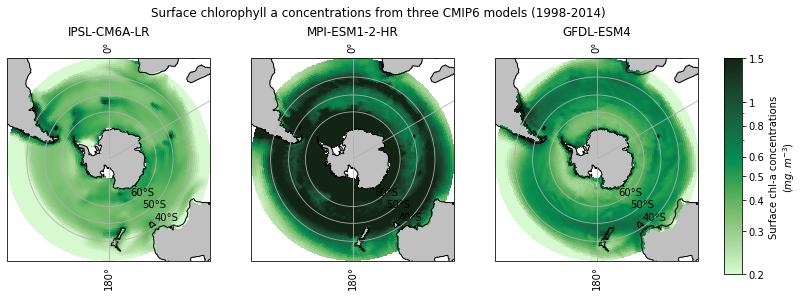

In [25]:
X,Y=np.meshgrid(lon,lat)

fig,axs = plt.subplots(ncols=3,nrows=1,figsize=(12,4),subplot_kw={'projection': ccrs.SouthPolarStereo()})

for i in np.arange(3):
    axs[i].coastlines(resolution='110m')

    axs[i].add_feature(cfeature.LAND, color='silver', zorder=1)
    gl=axs[i].gridlines(draw_labels=True)
    gl.xlocator = mticker.FixedLocator([0,60,180,240,300])
    gl.ylocator = mticker.FixedLocator([-60,-50,-40])


im=axs[0].pcolormesh(X,Y,1e3*chl_IPSL_yearly[:,:],cmap=cmocean.cm.algae,norm=matplotlib.colors.LogNorm(vmin=2e-1,vmax=1.5),transform=ccrs.PlateCarree())
axs[1].pcolormesh(X,Y,1e6*chl_MPI_yearly[:,:],cmap=cmocean.cm.algae,norm=matplotlib.colors.LogNorm(vmin=2e-1,vmax=1.5),transform=ccrs.PlateCarree())
axs[2].pcolormesh(X,Y,1e6*chl_ESM4_yearly[:,:],cmap=cmocean.cm.algae,norm=matplotlib.colors.LogNorm(vmin=2e-1,vmax=1.5),transform=ccrs.PlateCarree())

cbar_ax=fig.add_axes([0.9,0.05,0.02,0.75])
cbar=fig.colorbar(im,cax=cbar_ax,orientation='vertical',ticks=[2e-1,3e-1,4e-1, 5e-1,6e-1,8e-1,1,1.5])
cbar.ax.set_yticklabels(['0.2','0.3','0.4', '0.5','0.6','0.8','1','1.5'],fontsize=10)
cbar.set_label('Surface chl-a concentrations\n$(mg.m^{-3})$',fontsize=10)

axs[0].set_title("IPSL-CM6A-LR")
axs[1].set_title("MPI-ESM1-2-HR")
axs[2].set_title("GFDL-ESM4")

plt.suptitle("Surface chlorophyll a concentrations from three CMIP6 models (1998-2014)")
fig.subplots_adjust(bottom=0.05, top=0.85, left=0.07, right=0.87,wspace=0.2)
plt.show()